# Customer Churn Prediction

Machine learning project for identifying telecom customers who are likely to churn.

## Project objective

The objective is to build and evaluate a classification model that can help a retention team prioritize customers for proactive contact.


In [1]:
from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive/projects/customer-churn-prediction")
except ImportError:
    PROJECT_DIR = Path.cwd()
    if PROJECT_DIR.name == "notebooks":
        PROJECT_DIR = PROJECT_DIR.parent

print(f"Project directory: {PROJECT_DIR}")


Mounted at /content/drive
Project directory: /content/drive/MyDrive/projects/customer-churn-prediction


In [2]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


## Data loading

Load the original CSV file and verify that the dataset is available in the expected project folder.


In [3]:
df = pd.read_csv(PROJECT_DIR / "data" / "customer_churn.csv")

df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [4]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.info()


Rows: 3,150
Columns: 14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtype

## Data quality and exploratory analysis

Check column meanings, missing values, duplicates, class balance, and possible data leakage before modeling.

In [5]:
# Check whether missing or duplicate records need attention.
print("Missing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

# Check how many customers churned.
print("\nChurn counts:")
print(df["Churn"].value_counts())

Missing values:
Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64

Duplicate rows: 300

Churn counts:
Churn
0    2655
1     495
Name: count, dtype: int64


In [6]:
# Check which churn classes contain the extra duplicate rows.
print("Extra duplicates by Churn:")
print(df.loc[df.duplicated(), "Churn"].value_counts())

print("\nChurn share before removal:")
print(df["Churn"].value_counts(normalize=True).round(3))

df_clean = df.drop_duplicates().copy()

print("\nChurn share after removal:")
print(df_clean["Churn"].value_counts(normalize=True).round(3))
print("Rows after removal:", len(df_clean))

Extra duplicates by Churn:
Churn
0    251
1     49
Name: count, dtype: int64

Churn share before removal:
Churn
0    0.843
1    0.157
Name: proportion, dtype: float64

Churn share after removal:
Churn
0    0.844
1    0.156
Name: proportion, dtype: float64
Rows after removal: 2850


In [7]:
# Compare churn rates for customers with and without complaints.
complaints_churn = df_clean.groupby("Complains")["Churn"].agg(["count", "mean"])

complaints_churn["mean"] = (complaints_churn["mean"] * 100).round(1)
complaints_churn = complaints_churn.rename(
    columns={"count": "Customers", "mean": "Churn rate (%)"}
)

complaints_churn

,Customers,Churn rate (%)
Complains,,
0,2620,9.8
1,230,82.6


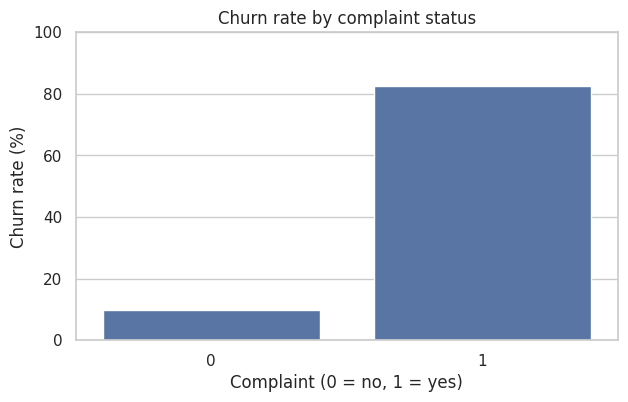

In [8]:
# Compare churn rates; keep the scale at 0–100% for a fair comparison.
plt.figure(figsize=(7, 4))

sns.barplot(
    data=complaints_churn.reset_index(),
    x="Complains",
    y="Churn rate (%)"
)

plt.ylim(0, 100)
plt.xlabel("Complaint (0 = no, 1 = yes)")
plt.ylabel("Churn rate (%)")
plt.title("Churn rate by complaint status")
plt.show()

Churn
0    64.0
1    29.0
Name: Frequency of use, dtype: float64


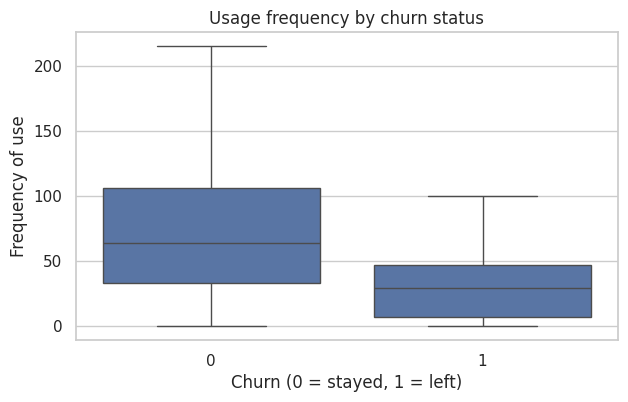

In [9]:
# Compare typical usage between retained and churned customers.
print(df_clean.groupby("Churn")["Frequency of use"].median())

plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df_clean,
    x="Churn",
    y="Frequency of use",
    showfliers=False
)

plt.xlabel("Churn (0 = stayed, 1 = left)")
plt.ylabel("Frequency of use")
plt.title("Usage frequency by churn status")
plt.show()

Customers who churned generally used the service less frequently than customers who stayed. Usage frequency may be useful for identifying customers at risk of churn.

In [10]:
# Inspect how churn differs across Status values.
status_churn = df_clean.groupby("Status")["Churn"].agg(["count", "mean"])
status_churn["mean"] = (status_churn["mean"] * 100).round(1)
status_churn.rename(
    columns={"count": "Customers", "mean": "Churn rate (%)"}
)

,Customers,Churn rate (%)
Status,,
1,2166,5.6
2,684,47.5


In [11]:
from sklearn.model_selection import train_test_split

# Start with a model that does not use the customer's current Status.
X = df_clean.drop(columns=["Churn", "Status"])
y = df_clean["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Churn rate in training:", round(y_train.mean() * 100, 1), "%")
print("Churn rate in test:", round(y_test.mean() * 100, 1), "%")

Training rows: 2280
Test rows: 570
Churn rate in training: 15.7 %
Churn rate in test: 15.6 %


In [12]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score

# Baseline predicts the most common class from the training data.
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, baseline_predictions), 3))
print("Recall for churn:", round(recall_score(y_test, baseline_predictions), 3))

Accuracy: 0.844
Recall for churn: 0.0


In [13]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score

# Scale features using training data, then fit a churn classifier.
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight="balanced", max_iter=1000)
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, predictions), 3))
print("Precision for churn:", round(precision_score(y_test, predictions), 3))
print("Recall for churn:", round(recall_score(y_test, predictions), 3))

Accuracy: 0.807
Precision for churn: 0.441
Recall for churn: 0.876


In [14]:
from sklearn.metrics import confusion_matrix

# Rows are actual outcomes; columns are model predictions.
cm = confusion_matrix(y_test, predictions)

print("Stayed, predicted stayed:", cm[0, 0])
print("Stayed, predicted left:", cm[0, 1])
print("Left, predicted stayed:", cm[1, 0])
print("Left, predicted left:", cm[1, 1])

Stayed, predicted stayed: 382
Stayed, predicted left: 99
Left, predicted stayed: 11
Left, predicted left: 78


The logistic regression model identified 78 of 89 churned customers (87.6% recall), while missing 11. It also flagged 99 customers who stayed, resulting in 44.1% precision. The model can help find customers at risk, but the cost of false alerts should be considered before use.

In [15]:
from sklearn.base import clone

# Set aside part of the training data to compare thresholds.
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

threshold_model = clone(model)
threshold_model.fit(X_fit, y_fit)
scores = threshold_model.predict_proba(X_val)[:, 1]

for threshold in [0.5, 0.7]:
    val_predictions = (scores >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print("Flagged customers:", val_predictions.sum())
    print("Precision:", round(precision_score(y_val, val_predictions), 3))
    print("Recall:", round(recall_score(y_val, val_predictions), 3))


Threshold: 0.5
Flagged customers: 184
Precision: 0.457
Recall: 0.944

Threshold: 0.7
Flagged customers: 110
Precision: 0.6
Recall: 0.742


On the validation set, a 0.5 threshold found more churned customers than 0.7 (84 vs 66), but produced more false alerts (100 vs 44). This threshold comparison applies only to logistic regression. The final random forest is evaluated with its default threshold. Choosing an outreach threshold would require contact and churn costs.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    class_weight="balanced",
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Compare models across the same five training folds.
for name, candidate in [
    ("Logistic regression", model),
    ("Random forest", forest)
]:
    result = cross_validate(
        candidate,
        X_train,
        y_train,
        cv=cv,
        scoring={"precision": "precision", "recall": "recall"}
    )

    print(name)
    print("Mean precision:", round(result["test_precision"].mean(), 3))
    print("Mean recall:", round(result["test_recall"].mean(), 3))

Logistic regression
Mean precision: 0.464
Mean recall: 0.865
Random forest
Mean precision: 0.545
Mean recall: 0.891


In [17]:
# Fit the selected model on all training rows, then evaluate it on the holdout set.
forest.fit(X_train, y_train)
forest_predictions = forest.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, forest_predictions), 3))
print("Precision:", round(precision_score(y_test, forest_predictions), 3))
print("Recall:", round(recall_score(y_test, forest_predictions), 3))

forest_cm = confusion_matrix(y_test, forest_predictions)
print("\nConfusion matrix:")
print(forest_cm)

Accuracy: 0.863
Precision: 0.536
Recall: 0.91

Confusion matrix:
[[411  70]
 [  8  81]]


In [18]:
# Rank features by their contribution to the forest's splits.
importance = pd.Series(
    forest.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(10)

,0
Complains,0.213079
Customer Value,0.170956
Seconds of Use,0.161871
Frequency of use,0.138755
Frequency of SMS,0.079972
Distinct Called Numbers,0.068986
Subscription Length,0.043457
Charge Amount,0.036303
Call Failure,0.029801
Age Group,0.029385


In [19]:
# Compare typical feature values for stayed and churned customers.
df_clean.groupby("Churn")[
    ["Customer Value", "Seconds of Use", "Frequency of SMS"]
].median()

,Customer Value,Seconds of Use,Frequency of SMS
Churn,,,
0,271.540,3596.5,26.0
1,102.565,1256.5,11.0


Customers who churned had lower median call frequency, call duration, SMS frequency, and Customer Value. These patterns describe an association with churn and may help identify customers for retention outreach.

In [20]:
from joblib import dump

# Save the fitted model for later predictions.
model_path = PROJECT_DIR / "models" / "churn_forest.joblib"
model_path.parent.mkdir(parents=True, exist_ok=True)

dump(forest, model_path)
print("Saved model:", model_path)

Saved model: /content/drive/MyDrive/projects/customer-churn-prediction/models/churn_forest.joblib


In [21]:
from joblib import load

# Load the saved model and keep one row in DataFrame format.
saved_model = load(model_path)
example_client = X_test.iloc[[0]]

prediction = saved_model.predict(example_client)[0]
score = saved_model.predict_proba(example_client)[0, 1]

print("Prediction:", prediction)
print("Churn score:", round(score, 3))

Prediction: 1
Churn score: 0.815


In [22]:
print("Actual churn:", y_test.iloc[0])

Actual churn: 1


## Model results

The random forest performed better than logistic regression on the held-out test set.

| Model | Accuracy | Precision | Recall |
|---|---:|---:|---:|
| Majority-class baseline | 0.844 | 0.000 | 0.000 |
| Logistic regression | 0.807 | 0.441 | 0.876 |
| Random forest | 0.863 | 0.536 | 0.910 |

The random forest identified 81 of 89 churned customers. It missed 8 customers
and produced 70 false alerts. It can help a retention team prioritize outreach,
but the best decision threshold depends on the costs of outreach and churn.

The Status feature was excluded from model training. Exact duplicate rows were
removed, although the dataset has no customer ID to confirm that they represent
the same person.